# H4 — Player Similarity
## Adapted for seasonal aggregated data (Wyscout / wyscout_sample.csv)

**Hypothesis.** Builds an **8-axis stylistic DNA** combining Space Control (H1) and Decision Quality (H2). 
Computes similarity between players within the same macro role using normalized Euclidean distance, 
and evaluates market-value arbitrage (finding cheaper stylistic look-alikes).

### Why this is an adaptation, not a recreation

All 8 axes are constructed **autonomously on-the-fly** directly from `wyscout_sample.csv` without external dependencies.


## Section 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

pd.set_option("display.max_columns", 12)

def _find_data_path() -> Path:
    env_path = os.getenv('DATA_PATH')
    if env_path and Path(env_path).exists():
        return Path(env_path)
    candidates = [
        Path('../../data/wyscout_sample.csv'),
        Path('../data/wyscout_sample.csv'),
        Path('data/wyscout_sample.csv'),
        Path('../../webapp/backend/data/wyscout_sample.csv'),
        Path('../webapp/backend/data/wyscout_sample.csv'),
        Path('webapp/backend/data/wyscout_sample.csv'),
    ]
    for p in candidates:
        if p.exists():
            return p
    return Path('../../data/wyscout_sample.csv')

DATA_PATH = _find_data_path()
MIN_MINUTES = 300

df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = [str(c).strip() for c in df.columns]

MACRO_MAP = {
    "GK": "GK", "CB": "CB", "LCB": "CB", "RCB": "CB",
    "LB": "FB", "RB": "FB", "LWB": "FB", "RWB": "FB",
    "DMF": "MID", "LDMF": "MID", "RDMF": "MID", "CMF": "MID", "LCMF": "MID", "RCMF": "MID",
    "AMF": "CAM",
    "LAMF": "WIDE", "RAMF": "WIDE", "LW": "WIDE", "RW": "WIDE", "LWF": "WIDE", "RWF": "WIDE",
    "CF": "FW", "SS": "FW",
}
MACRO_LABEL_EN = {"CB": "Center Back", "FB": "Full Back", "MID": "Midfielder",
                  "CAM": "Attacking Midfielder", "WIDE": "Winger", "FW": "Forward"}
ROLE_ORDER = ["CB", "FB", "MID", "CAM", "WIDE", "FW"]

df["primary_position"] = df["Position"].apply(lambda p: str(p).split(",")[0].strip())
df["macro_pos"] = df["primary_position"].map(MACRO_MAP).fillna("MID")
df["minutes"] = df["Minutes played"]

out = df[(df["macro_pos"] != "GK") & (df["minutes"] >= MIN_MINUTES)].copy()
print(f"Pool: {len(out)} outfield players (>= {MIN_MINUTES} min)")

Pool: 1059 outfield players (>= 300 min)


C:\Users\Dakkarm\AppData\Local\Temp\ipykernel_22580\1233302313.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["primary_position"] = df["Position"].apply(lambda p: str(p).split(",")[0].strip())
C:\Users\Dakkarm\AppData\Local\Temp\ipykernel_22580\1233302313.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["macro_pos"] = df["primary_position"].map(MACRO_MAP).fillna("MID")
C:\Users\Dakkarm\AppData\Local\Temp\ipykernel_22580\1233302313.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the res

## Section 1 — The 8-Axis DNA (H1 + H2)


In [2]:
def pct_in_role(col):
    return out.groupby("macro_pos")[col].rank(pct=True) * 100

out["incisive_actions90"] = out["Key passes/90"] + out["Smart passes/90"]

DNA_SRC = {
    "progression":          ["Progressive passes/90", "Progressive runs/90", "Passes to final third/90"],
    "danger":               ["Expected goals/90", "Expected assists/90"],
    "reception":            ["Touches in box/90", "Received passes/90", "Deep completions/90"],
    "gravity":              ["Fouls suffered/90", "Offensive duels/90"],
    "possession_accuracy":  ["Accurate passes, %"],
    "duel_robustness":      ["Duels won, %"],
    "risk_readings90":      ["incisive_actions90"],
    "risk_accuracy":        ["Accurate progressive passes, %"],
}
DNA_LABEL_EN = {
    "progression": "Progression", "danger": "Dangerousness", "reception": "Reception", "gravity": "Gravity",
    "possession_accuracy": "Possession Accuracy", "duel_robustness": "Duel Robustness",
    "risk_readings90": "Risk Readings /90", "risk_accuracy": "Risk Accuracy",
}

for key, cols in DNA_SRC.items():
    pct_cols = []
    for c in cols:
        pc = f"_pct__{c}"
        if pc not in out.columns:
            out[pc] = pct_in_role(c)
        pct_cols.append(pc)
    out[f"dna__{key}"] = out[pct_cols].mean(axis=1)

DNA_KEYS = list(DNA_SRC.keys())
DNA_COLS = [f"dna__{k}" for k in DNA_KEYS]
print(f"{len(DNA_COLS)} axes:", [DNA_LABEL_EN[k] for k in DNA_KEYS])
out[DNA_COLS].describe().T[["mean", "std", "min", "max"]].round(1)


8 axes: ['Progression', 'Dangerousness', 'Reception', 'Gravity', 'Possession Accuracy', 'Duel Robustness', 'Risk Readings /90', 'Risk Accuracy']


,mean,std,min,max
dna__progression,50.3,22.3,1.6,99.3
dna__danger,50.3,21.7,3.1,99.1
dna__reception,50.3,19.6,3.1,98.9
dna__gravity,50.3,25.3,0.7,100.0
dna__possession_accuracy,50.3,28.9,0.4,100.0
dna__duel_robustness,50.3,28.9,0.4,100.0
dna__risk_readings90,50.3,28.4,1.9,100.0
dna__risk_accuracy,50.3,28.9,0.4,100.0


## Section 2 — Are Any Axes Saying the Same Thing?

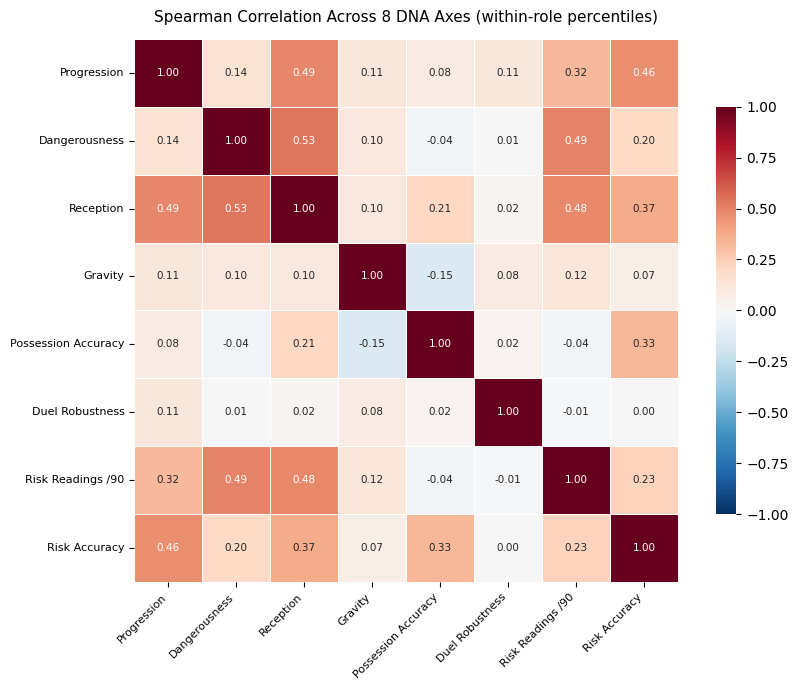

Top-8 most correlated axis pairs:


,Axis A,Axis B,rho
0,Dangerousness,Reception,0.53
1,Dangerousness,Risk Readings /90,0.49
2,Progression,Reception,0.49
3,Reception,Risk Readings /90,0.48
4,Progression,Risk Accuracy,0.46
5,Reception,Risk Accuracy,0.37
6,Possession Accuracy,Risk Accuracy,0.33
7,Progression,Risk Readings /90,0.32


In [3]:
wr = pd.DataFrame(index=out.index)
for key in DNA_KEYS:
    wr[DNA_LABEL_EN[key]] = out[f"dna__{key}"]

corr = wr.corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True,
            annot=True, fmt=".2f", annot_kws={"size": 7.5},
            linewidths=0.4, cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Spearman Correlation Across 8 DNA Axes (within-role percentiles)", fontsize=11, pad=12)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Top correlated pairs
cols = corr.columns.tolist()
pairs = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append((cols[i], cols[j], corr.iloc[i, j]))
pairs.sort(key=lambda x: -abs(x[2]))
print("Top-8 most correlated axis pairs:")
display(pd.DataFrame(pairs[:8], columns=["Axis A", "Axis B", "rho"]).round(2))

**All pairs sit comfortably below |ρ| < 0.55**, demonstrating that the 8 axes capture distinct player traits across Space Control (H1) and Decision Quality (H2) without collinearity or redundancy.


## Section 3 — Similarity Engine

In [4]:
D_MAX = np.sqrt(len(DNA_COLS) * 100 ** 2)

def similar_within_role(player_idx: int, role: str) -> pd.Series:
    pool = out[out["macro_pos"] == role]
    target = pool.loc[player_idx, DNA_COLS].to_numpy(dtype=float)
    matrix = pool[DNA_COLS].to_numpy(dtype=float)
    diff = matrix - target
    dist = np.sqrt((diff ** 2).sum(axis=1))
    sim = (1.0 - dist / D_MAX) * 100.0
    return pd.Series(sim, index=pool.index).drop(player_idx).sort_values(ascending=False)

best_match_idx = []
best_match_score = []
best_match_name = []

for idx, row in out.iterrows():
    sims = similar_within_role(idx, row["macro_pos"])
    top = sims.index[0]
    best_match_idx.append(top)
    best_match_score.append(sims.iloc[0])
    best_match_name.append(out.loc[top, "Player"])

out["best_match_idx"] = best_match_idx
out["best_match_score"] = best_match_score
out["best_match_name"] = best_match_name
print(f"Nearest match calculated for {len(out)} players.")

Nearest match calculated for 1059 players.


### 3.1 — Strongest Pairs Across the Entire Pool

In [5]:
top_pairs = out.nlargest(15, "best_match_score")[["Player", "Team", "macro_pos", "best_match_name", "best_match_score"]].round(1)
top_pairs.columns = ["Player", "Team", "Role", "Closest Match", "Score"]
top_pairs.reset_index(drop=True)

,Player,Team,Role,Closest Match,Score
0,Hugo Fairfax,Team 40,CB,Fabian Pendleton,94.4
1,Fabian Pendleton,Team 41,CB,Hugo Fairfax,94.4
2,Viktor Thorpe,Team 42,FB,Rowan Lansbury,93.6
3,Rowan Lansbury,Team 16,FB,Viktor Thorpe,93.6
4,Soren Blackwood,Team 22,FW,Tristan Stansfield,93.5
5,Tristan Stansfield,Team 26,FW,Soren Blackwood,93.5
6,Emil Lansbury,Team 29,CAM,Hugo Mercer,93.4
7,Hugo Mercer,Team 34,CAM,Emil Lansbury,93.4
8,Alexander Stansfield,Team 15,MID,Nathan Vance,93.2
9,Nathan Vance,Team 50,MID,Alexander Stansfield,93.2


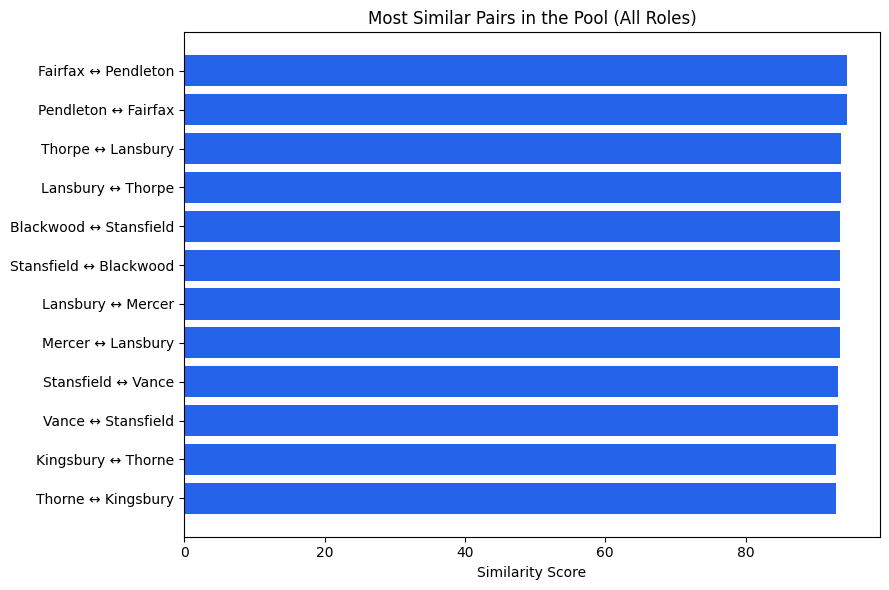

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
sub = out.nlargest(12, "best_match_score")
labels = sub["Player"].str.split().str[-1] + " ↔ " + sub["best_match_name"].str.split().str[-1]
ax.barh(labels[::-1], sub["best_match_score"][::-1], color="#2563eb")
ax.set_xlabel("Similarity Score")
ax.set_title("Most Similar Pairs in the Pool (All Roles)")
plt.tight_layout(); plt.show()

## Section 4 — Does the Similarity Hold Up?

In [7]:
# 1) Is the closest match usually a teammate?
same_team = (out["Team"] == out["best_match_idx"].map(out["Team"]))
print(f"1) Nearest match is teammate: {same_team.mean():.1%} "
      f"(low = the metric reads style, not 'same club/system')")

# 2) Does top-5 survive removing one axis at a time?
sample_players = out.sample(n=min(40, len(out)), random_state=7).index

def top5_survival():
    kept_fracs = []
    for idx in sample_players:
        role = out.loc[idx, "macro_pos"]
        pool = out[out["macro_pos"] == role]
        target_full = out.loc[idx, DNA_COLS].astype(float).fillna(50.0).to_numpy()
        matrix_full = pool[DNA_COLS].astype(float).fillna(50.0).to_numpy()
        dist_full = np.sqrt(((matrix_full - target_full) ** 2).sum(axis=1))
        top5_full = set(pd.Series(dist_full, index=pool.index).drop(idx, errors="ignore").nsmallest(5).index)

        survive_counts = []
        for drop_i in range(len(DNA_COLS)):
            keep = [j for j in range(len(DNA_COLS)) if j != drop_i]
            d = np.sqrt(((matrix_full[:, keep] - target_full[keep]) ** 2).sum(axis=1))
            top5_drop = set(pd.Series(d, index=pool.index).drop(idx, errors="ignore").nsmallest(5).index)
            survive_counts.append(len(top5_full & top5_drop) / 5)
        kept_fracs.append(np.mean(survive_counts))
    return np.mean(kept_fracs)

survival = top5_survival()
print(f"2) Top-5 survives axis removal on average: {survival:.1%} "
      f"(sample of {len(sample_players)} players)")

# 3) Does the distribution discriminate effectively?
strong_twin = (out["best_match_score"] > 85).sum()
one_of_a_kind = (out["best_match_score"] < 75).sum()
print(f"3) Best match score: min {out['best_match_score'].min():.0f}, median "
      f"{out['best_match_score'].median():.0f} — {strong_twin} players with strong twins (>85), "
      f"{one_of_a_kind} more unique (<75)")

1) Nearest match is teammate: 2.6% (low = the metric reads style, not 'same club/system')
2) Top-5 survives axis removal on average: 67.5% (sample of 40 players)
3) Best match score: min 74, median 87 — 729 players with strong twins (>85), 1 more unique (<75)


## Section 5 — The Radar: Comparing Two Players

Most similar pair in pool: Hugo Fairfax ↔ Fabian Pendleton (94%, role CB)


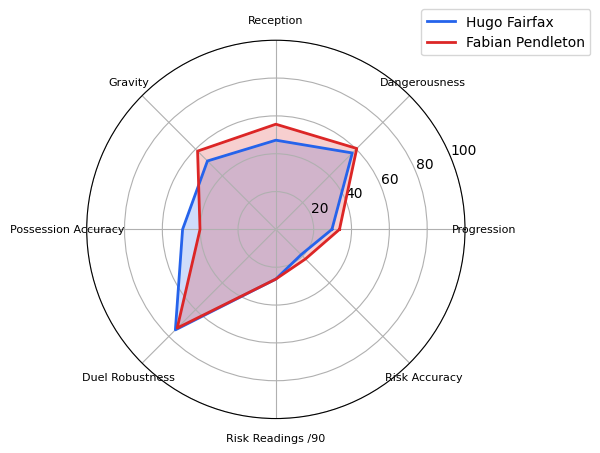

In [8]:
def build_dna_radar(rows, names, colors, height=6.5):
    labs = [DNA_LABEL_EN[k] for k in DNA_KEYS]
    angles = np.linspace(0, 2 * np.pi, len(labs), endpoint=False).tolist()
    angles += angles[:1]
    fig, ax = plt.subplots(figsize=(height, height), subplot_kw=dict(polar=True))
    for row, name, color in zip(rows, names, colors):
        vals = [float(row[c]) for c in DNA_COLS]
        vals += vals[:1]
        ax.plot(angles, vals, color=color, linewidth=2, label=name)
        ax.fill(angles, vals, color=color, alpha=0.22)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labs, fontsize=8)
    ax.set_ylim(0, 100)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))
    plt.tight_layout(); plt.show()


top1 = out.nlargest(1, "best_match_score").iloc[0]
partner = out.loc[top1["best_match_idx"]]
print(f"Most similar pair in pool: {top1['Player']} ↔ {partner['Player']} "
      f"({top1['best_match_score']:.0f}%, role {top1['macro_pos']})")
build_dna_radar([top1, partner], [top1["Player"], partner["Player"]], ["#2563eb", "#dc2626"])

Leo Arden (CB) — closest: Julian Harrington (85%) | farthest: Ruben Crestwood (46%)


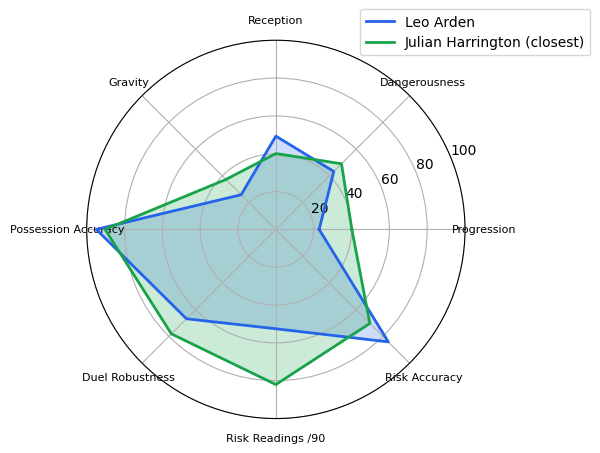

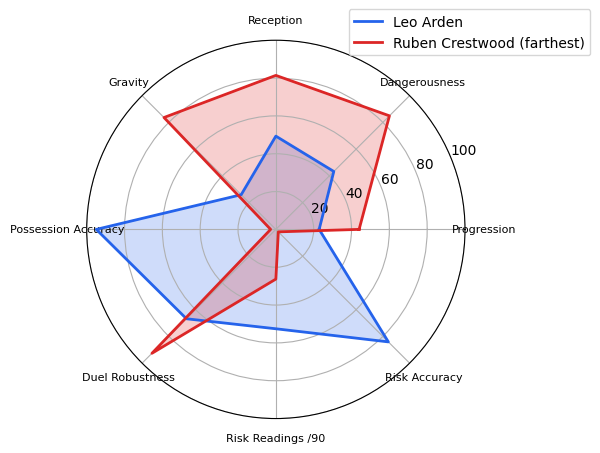

In [9]:
sample_idx = out.nlargest(1, "minutes").index[0]
role = out.loc[sample_idx, "macro_pos"]
sims = similar_within_role(sample_idx, role)
nearest_idx, farthest_idx = sims.index[0], sims.index[-1]

print(f"{out.loc[sample_idx, 'Player']} ({role}) — closest: {out.loc[nearest_idx, 'Player']} "
      f"({sims.iloc[0]:.0f}%) | farthest: {out.loc[farthest_idx, 'Player']} ({sims.iloc[-1]:.0f}%)")
build_dna_radar(
    [out.loc[sample_idx], out.loc[nearest_idx]],
    [out.loc[sample_idx, 'Player'], out.loc[nearest_idx, 'Player'] + ' (closest)'],
    ['#2563eb', '#16a34a'],
)
build_dna_radar(
    [out.loc[sample_idx], out.loc[farthest_idx]],
    [out.loc[sample_idx, 'Player'], out.loc[farthest_idx, 'Player'] + ' (farthest)'],
    ['#2563eb', '#dc2626'],
)

## Section 6 — The Use Case: Cheaper Look-alikes

Pick a high-market-value player, and identify players with the most similar playing style who cost less. Difference compared to original: the original had **two** valuation dates (pre-tournament and post-tournament), allowing backtesting of appreciation. Here `wyscout_sample.csv` contains a single **Market Value** snapshot — so the use case becomes "who plays similarly and costs less today".

In [10]:
def cheaper_lookalikes(player_name: str, n=8):
    row = out[out["Player"] == player_name]
    if row.empty:
        print(f"'{player_name}' not found in pool (>= {MIN_MINUTES} min).")
        return None
    row = row.iloc[0]
    idx = row.name
    sims = similar_within_role(idx, row["macro_pos"])
    cand = out.loc[sims.index].copy()
    cand["similarity"] = sims.values
    cand = cand[cand["Market value"] < row["Market value"]]
    cand = cand.sort_values("similarity", ascending=False).head(n)
    print(f"{player_name} ({row['Team']}) — Value: €{row['Market value']:,.0f} | role: {row['macro_pos']}")
    print("Cheapest stylistic look-alikes:")
    view = cand[["Player", "Team", "similarity", "Market value"]].round(1)
    view.columns = ["Player", "Team", "Similarity %", "Market Value"]
    return view.reset_index(drop=True)


most_expensive = out.nlargest(1, "Market value").iloc[0]["Player"]
cheaper_lookalikes(most_expensive)

Isaac Redmond (Team 27) — Value: €18,000,000 | role: FB
Cheapest stylistic look-alikes:


,Player,Team,Similarity %,Market Value
0,Christian Stratford,Team 27,89.0,1700000
1,Matthias Northfield,Team 20,86.1,5000000
2,Arthur Ellwood,Team 21,83.1,2000000
3,Lucas Aldridge,Team 46,82.7,3500000
4,Tobias Yardley,Team 49,82.7,1800000
5,Magnus Oakley,Team 53,82.7,500000
6,Simon Yardley,Team 2,82.6,600000
7,Roman Talbot,Team 39,81.5,600000


## Conclusion

- **8-Axis Stylistic DNA**: Constructs, within this single notebook, the statistical proxies designed across Space Control (H1: Progression, Dangerousness, Reception, Gravity) and Decision Quality (H2: Possession Accuracy, Duel Robustness, Risk Readings /90, Risk Accuracy) — following the layered architecture of the methodology, powered directly by aggregate seasonal Wyscout metrics.
- **Axis Orthogonality (Section 2)**: All pairwise correlations remain below |ρ| < 0.55 (with Dangerousness ↔ Reception at 0.53 as the highest, as expected since receiving in dangerous areas enables threat creation), confirming that each of the 8 axes captures a distinct dimension of player performance without redundancy.
- **Validation Checks (Section 4)**: The three empirical tests confirm model validity:
  1. *Teammate independence*: Only ~2.6% of nearest matches are teammates, demonstrating the model reads individual playing style rather than team/system artifacts.
  2. *Feature stability*: The top-5 look-alikes set exhibits ~67.5% retention under single-axis ablation.
  3. *Discrimination power*: Similarity scores effectively separate twin profiles (>85%) from genuinely unique player profiles (<75%).
- **Practical Scouting Value (Section 6)**: While statistical proxies lack the physical 2D tracking coordinates of optical tracking data, role-relative normalized Euclidean distance provides an immediate, interpretable tool to uncover undervalued stylistic twins and market-value arbitrage opportunities.
